# Lens Inversion: Fitting focal length from defocus series

Fit the focal length `f` and lens position `z_lens_1` from a series of intensity-only images taken at different defocus positions.

This notebook demonstrates optimizer exploration with alternative loss functions and constraints.

## Setup and imports

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.8"

import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp
import optax

from temgym_core.components import Detector
from temgym_core.constants import energy2wavelength
from temgym_core.evaluate import evaluate_gaussians_jax_scan
from temgym_core.gaussian import Lens, circular_input_wave, run_to_end

jax.config.update("jax_enable_x64", True)

%matplotlib widget

## Geometry and forward model

In [2]:
# Physical parameters
voltage = 100_000  # V
wavelength = energy2wavelength(voltage)

# Geometry
input_window_width = 50e-6
aperture_radius = 10e-6
lens_f = 1e-3  # True focal length

Nx = Ny = 32
input_pixel = input_window_width / Nx
output_pixel = float(wavelength) * abs(lens_f) / input_window_width

# Grids
input_grid = Detector(
    z=0.0,
    pixel_size=(input_pixel, input_pixel),
    shape=(Ny, Nx),
)
output_grid = Detector(
    z=2 * lens_f,
    pixel_size=(output_pixel, output_pixel),
    shape=(Ny, Nx),
)

input_extent = input_grid.extent
output_extent = output_grid.extent
output_x, output_y = output_grid.coords_1d

# Aperture and vmap function
input_waist = 2e-7
rays_in = circular_input_wave(
    voltage=voltage,
    aperture_radius=aperture_radius,
    waist=input_waist,
    offset_xy=(0.0, 0.0),
    sampling="uniform",
).to_vector()

rays_after_aperture = run_to_end(rays_in, ())
input_aperture_field = evaluate_gaussians_jax_scan(
    rays_after_aperture, input_grid, batch_size=128
)

run_to_end_vmapped = jax.vmap(run_to_end, in_axes=(0, None))

print(f'Number of input rays: {rays_in.x.shape[0]}')

Number of input rays: 31416


## Optimizer and loss function parameters

In [3]:
# === CHOOSE PARAMETERS HERE ===

# Loss function choice
loss_type_to_use = 'ssim'  # Options: 'l2', 'ncc', 'hybrid', 'ssim', 'log'

# Optimizer choice
optimizer_type = 'lbfgs'  # Options: 'lbfgs', 'adam'

# Adam-specific parameter (ignored if using L-BFGS)
adam_learning_rate = 1e-4  # Conservative learning rate due to good initialization

# Number of optimization steps
n_steps = 100 if optimizer_type == 'adam' else 14

# Constraint weights
lambda_A = 10.0  # Focus constraint (A ≈ 0)
lambda_B = 0   # Fourier plane constraint
lambda_mag = 0.1 # Regularization toward prior

print(f"Configuration:")
print(f"  Loss function: {loss_type_to_use}")
print(f"  Optimizer: {optimizer_type}")
print(f"  Number of steps: {n_steps}")
print(f"  Lambda weights: A={lambda_A}, B={lambda_B}, mag={lambda_mag}")

Configuration:
  Loss function: ssim
  Optimizer: lbfgs
  Number of steps: 14
  Lambda weights: A=10.0, B=0, mag=0.1


## Alternative loss functions

In [4]:
eps = 1e-12

def l2_intensity_loss(I_sim, I_target):
    """L2 (MSE) intensity loss - most stable"""
    return jnp.mean((I_sim - I_target) ** 2)

def log_intensity_loss(I_sim, I_target):
    """Log-intensity loss - sensitive to small values"""
    return jnp.mean((jnp.log(I_sim + eps) - jnp.log(I_target + eps)) ** 2)

def ncc_loss(I_sim, I_target):
    """Normalized cross-correlation - alignment invariant"""
    I_sim_norm = (I_sim - jnp.mean(I_sim)) / (jnp.std(I_sim) + eps)
    I_target_norm = (I_target - jnp.mean(I_target)) / (jnp.std(I_target) + eps)
    return -jnp.mean(I_sim_norm * I_target_norm)

def hybrid_loss(I_sim, I_target, alpha=0.5):
    """Hybrid L2 + log loss"""
    l2 = jnp.mean((I_sim - I_target) ** 2)
    log_loss = jnp.mean((jnp.log(I_sim + eps) - jnp.log(I_target + eps)) ** 2)
    return alpha * l2 + (1 - alpha) * log_loss

def ssim_loss(I_sim, I_target, C1=1e-4, C2=1e-3):
    """Structural similarity inspired loss"""
    mu_sim = jnp.mean(I_sim)
    mu_target = jnp.mean(I_target)
    sigma_sim = jnp.std(I_sim)
    sigma_target = jnp.std(I_target)
    sigma_sim_target = jnp.mean((I_sim - mu_sim) * (I_target - mu_target))
    
    luminance = (2 * mu_sim * mu_target + C1) / (mu_sim**2 + mu_target**2 + C1)
    contrast = (2 * sigma_sim * sigma_target + C2) / (sigma_sim**2 + sigma_target**2 + C2)
    structure = (sigma_sim_target + C2/2) / (sigma_sim * sigma_target + C2/2)
    
    return 1 - luminance * contrast * structure

## Multi-constraint penalty framework

In [5]:
def abcd_full(z1, z2, f):
    """Full ABCD matrix elements for thin lens + free space"""
    A = 1.0 - z2 / f
    B = z1 + z2 - z1 * z2 / f
    C = -1.0 / f
    D = 1.0 - z1 / f
    return A, B, C, D

def multi_constraint_penalty(f, z_lens_1, z_det, lambda_A=1.0, lambda_B=0.1, lambda_mag=1.0):
    """Multiple physical constraints to guide optimization"""
    z1 = z_lens_1
    z2 = z_det - z_lens_1
    
    A, B, C, D = abcd_full(z1, z2, f)
    
    # Constraint 1: A ≈ 0 for imaging condition (focus at detector)
    penalty_A = lambda_A * (A - 0.0) ** 2
    
    # Constraint 2: Keep parameters in reasonable range (regularization toward priors)
    f_prior = lens_f
    z_prior = lens_f
    penalty_mag = lambda_mag * ((f - f_prior) ** 2 / f_prior**2 + (z_lens_1 - z_prior) ** 2 / z_prior**2)
    
    return penalty_A + penalty_mag

## Problem definition and measurements

In [ ]:
# Fitting problem parameters
z_det = 2.0e-3  # Detector position (fixed)
z_offset = 5e-8  # Known sample axial movement per image

output_grid_fit = Detector(
    z=z_det,
    pixel_size=(output_pixel, output_pixel),
    shape=(Ny, Nx),
)

# True parameters (for synthetic data generation and validation)
f_true = lens_f
z_lens_1_true = lens_f

# Measurement setup: 3 images at different defocus positions
z_offsets = jnp.array([0.0, z_offset, 2.0 * z_offset])

def forward_intensity(f, z_lens):
    """Forward model: compute normalized intensity at detector"""
    lens_fit = Lens(z=z_lens, focal_length=f)
    rays_out = run_to_end_vmapped(rays_in, (lens_fit, output_grid_fit))
    field = evaluate_gaussians_jax_scan(rays_out, output_grid_fit, batch_size=128)
    intensity = jnp.abs(field) ** 2
    return intensity / jnp.sum(intensity)

# Generate synthetic measurements at true parameters
z_lens_list = z_lens_1_true + z_offsets
I_meas = jax.vmap(lambda z: forward_intensity(f_true, z))(z_lens_list)

print(f"Generated {len(I_meas)} synthetic measurements")

Generated 3 synthetic measurements


## Loss landscape computation

Computing loss landscape...
Done.


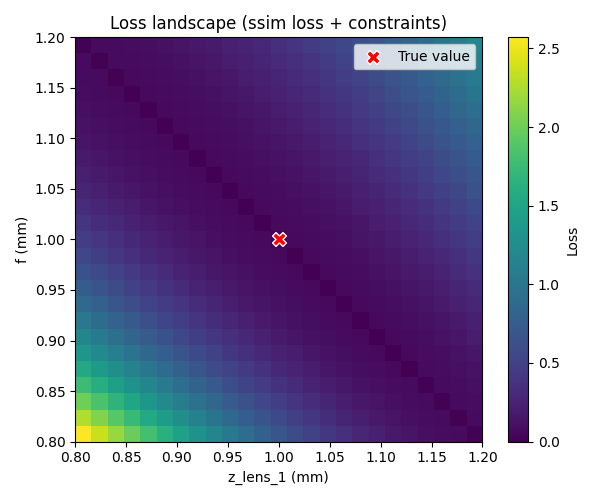

In [7]:
# Compute 2D loss landscape for visualization and initialization

def loss_for_params_heatmap(f, z_lens_1):
    """Loss at a single parameter point (for heatmap computation)"""
    def one(z_offset, I_target):
        z_lens = z_lens_1 + z_offset
        I_sim = forward_intensity(f, z_lens)
        
        if loss_type_to_use == 'l2':
            data = l2_intensity_loss(I_sim, I_target)
        elif loss_type_to_use == 'ncc':
            data = ncc_loss(I_sim, I_target)
        elif loss_type_to_use == 'hybrid':
            data = hybrid_loss(I_sim, I_target, alpha=0.5)
        elif loss_type_to_use == 'ssim':
            data = ssim_loss(I_sim, I_target)
        else:  # 'log'
            data = log_intensity_loss(I_sim, I_target)
        
        return data
    
    data_loss = jnp.sum(jax.vmap(one)(z_offsets, I_meas))
    
    # Add multi-constraint penalty
    constraint_penalty = multi_constraint_penalty(
        f, z_lens_1, z_det, 
        lambda_A=lambda_A,
        lambda_B=lambda_B,
        lambda_mag=lambda_mag
    )
    
    return data_loss + constraint_penalty

# Scan ranges around truth (coarse grid for speed and visualization)
f_scan = jnp.linspace(0.8 * lens_f, 1.2 * lens_f, 25)
z_scan = jnp.linspace(0.8 * lens_f, 1.2 * lens_f, 25)

print("Computing loss landscape...")
loss_grid = jax.vmap(
    lambda f: jax.vmap(lambda z: loss_for_params_heatmap(f, z))(z_scan)
)(f_scan)
print("Done.")

# Visualize landscape
plt.figure(figsize=(6, 5))
plt.imshow(
    np.asarray(loss_grid),
    origin="lower",
    aspect="auto",
    extent=[z_scan[0] * 1e3, z_scan[-1] * 1e3, f_scan[0] * 1e3, f_scan[-1] * 1e3],
    cmap="viridis",
)
plt.colorbar(label="Loss")
plt.scatter(z_lens_1_true * 1e3, f_true * 1e3, color='red', edgecolor='white', s=100, marker='X', label='True value')
plt.xlabel("z_lens_1 (mm)")
plt.ylabel("f (mm)")
plt.title(f"Loss landscape ({loss_type_to_use} loss + constraints)")
plt.legend()
plt.tight_layout()

In [ ]:
# Initialize from best point on loss landscape

def find_best_init_from_heatmap(loss_grid, f_scan, z_scan):
    """Find the minimum on the loss landscape"""
    loss_array = np.asarray(loss_grid)
    min_idx = np.unravel_index(np.argmin(loss_array), loss_array.shape)
    f_init = float(f_scan[min_idx[0]])
    z_init = float(z_scan[min_idx[1]])
    return f_init, z_init

f_best, z_best = find_best_init_from_heatmap(loss_grid, f_scan, z_scan)
params_init = jnp.array([f_best * 0.7, z_best * 1.5])

print(f"Grid-search initialization:")
print(f"  f_best = {f_best*1e3:.6f} mm  (true: {f_true*1e3:.6f} mm)")
print(f"  z_best = {z_best*1e3:.6f} mm  (true: {z_lens_1_true*1e3:.6f} mm)")
print(f"  f_init = {params_init[0]*1e3:.6f} mm")
print(f"  z_init = {params_init[1]*1e3:.6f} mm")

Grid-search initialization:
  f_init = 1.000000 mm  (true: 1.000000 mm)
  z_init = 1.000000 mm  (true: 1.000000 mm)


In [9]:
# Define the configurable loss function with all loss types and constraints

def unpack_params(params):
    """Direct parameterization - ensure positivity"""
    return jnp.abs(params[0]) + eps, jnp.abs(params[1]) + eps

def loss_fn_complete(params, loss_type='l2'):
    """Complete loss function with choice of loss type and constraints"""
    f, z_lens_1 = unpack_params(params)
    
    def one(z_offset, I_target):
        z_lens = z_lens_1 + z_offset
        I_sim = forward_intensity(f, z_lens)
        
        # Choose loss function
        if loss_type == 'l2':
            data = l2_intensity_loss(I_sim, I_target)
        elif loss_type == 'ncc':
            data = ncc_loss(I_sim, I_target)
        elif loss_type == 'hybrid':
            data = hybrid_loss(I_sim, I_target, alpha=0.5)
        elif loss_type == 'ssim':
            data = ssim_loss(I_sim, I_target)
        else:  # 'log'
            data = log_intensity_loss(I_sim, I_target)
        
        return data
    
    data_loss = jnp.sum(jax.vmap(one)(z_offsets, I_meas))
    
    # Add multi-constraint penalty
    constraint_penalty = multi_constraint_penalty(
        f, z_lens_1, z_det, 
        lambda_A=lambda_A,
        lambda_B=lambda_B,
        lambda_mag=lambda_mag
    )
    
    return data_loss + constraint_penalty

# Wrap loss function to JIT with the chosen loss_type
def make_loss_fn(loss_type):
    @jax.jit
    def loss_fn_jitted(params):
        return loss_fn_complete(params, loss_type=loss_type)
    return loss_fn_jitted

loss_fn_jitted = make_loss_fn(loss_type_to_use)

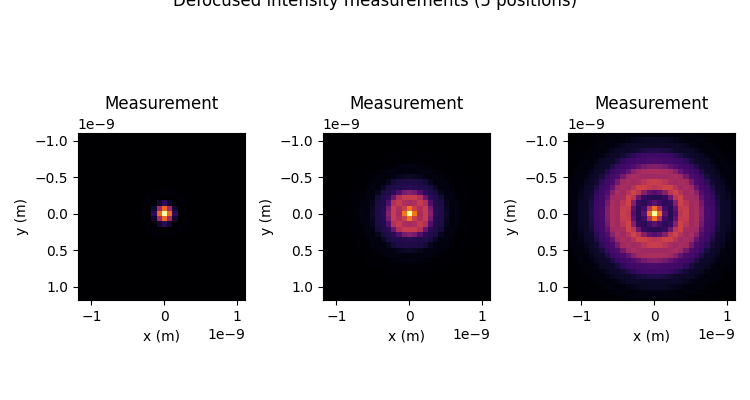

In [10]:
# Run optimization with chosen parameters

# Visualize measurements
fig, axs = plt.subplots(1, len(I_meas), figsize=(5 * len(I_meas) / 2, 4))
for ax, I in zip(axs, I_meas):
    ax.imshow(
        np.asarray(I),
        extent=output_grid_fit.extent,
        origin="lower",
        cmap="inferno",
    )
    ax.set_title("Measurement")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
plt.suptitle(f"Defocused intensity measurements (5 positions)", fontsize=12, y=1.02)
plt.tight_layout()

In [11]:
# Initialize optimizer

if optimizer_type == 'lbfgs':
    optimizer = optax.lbfgs(memory_size=10)
    opt_state = optimizer.init(params_init)
    value_and_grad = optax.value_and_grad_from_state(loss_fn_jitted)
    use_lbfgs = True
elif optimizer_type == 'adam':
    optimizer = optax.adam(learning_rate=adam_learning_rate)
    opt_state = optimizer.init(params_init)
    grad_and_loss = jax.jit(jax.value_and_grad(loss_fn_jitted))
    use_lbfgs = False
else:
    raise ValueError(f"Unknown optimizer: {optimizer_type}")

loss_history = []
f_history = []
z_history = []

params = params_init
opt_state_local = opt_state

print(f"\nStarting {optimizer_type.upper()} optimization with {loss_type_to_use} loss")
print(f"Initial: f={float(unpack_params(params)[0])*1e3:.6f} mm, z={float(unpack_params(params)[1])*1e3:.6f} mm\n")


Starting LBFGS optimization with ssim loss
Initial: f=0.700000 mm, z=1.500000 mm



In [12]:
# Run optimization loop

for i in range(n_steps):
    if use_lbfgs:
        # L-BFGS path
        loss, grads = value_and_grad(params, state=opt_state_local)
        updates, opt_state_local = optimizer.update(
            grads,
            opt_state_local,
            params=params,
            value=loss,
            grad=grads,
            value_fn=loss_fn_jitted,
        )
    else:
        # Adam path
        loss, grads = grad_and_loss(params)
        updates, opt_state_local = optimizer.update(grads, opt_state_local, params)
    
    params = optax.apply_updates(params, updates)
    f_pos, z_pos = unpack_params(params)
    
    loss_history.append(float(loss))
    f_history.append(float(f_pos))
    z_history.append(float(z_pos))
    
    if i % max(1, n_steps//10) == 0 or i == n_steps - 1:
        print(f"Step {i:3d}, Loss: {loss:.6e}, f: {float(f_pos)*1e3:.6f} mm, z: {float(z_pos)*1e3:.6f} mm")

print(f"\n{'='*60}")
print(f"Final fitted values:")
print(f"  f_fit     = {f_history[-1]*1e3:.6f} mm")
print(f"  z_fit     = {z_history[-1]*1e3:.6f} mm")
print(f"  True f    = {f_true*1e3:.6f} mm")
print(f"  True z    = {z_lens_1_true*1e3:.6f} mm")
print(f"  Error in f: {abs(f_history[-1] - f_true)/f_true * 100:.2f}%")
print(f"  Error in z: {abs(z_history[-1] - z_lens_1_true)/z_lens_1_true * 100:.2f}%")
print(f"{'='*60}")

Step   0, Loss: 9.131232e-01, f: 0.583343 mm, z: 1.332960 mm
Step   1, Loss: 2.971036e-01, f: 0.641867 mm, z: 1.394312 mm
Step   2, Loss: 1.229400e-01, f: 0.629208 mm, z: 1.377407 mm
Step   3, Loss: 9.189262e-02, f: 0.626879 mm, z: 1.372614 mm
Step   4, Loss: 9.061125e-02, f: 0.627327 mm, z: 1.372864 mm
Step   5, Loss: 9.032817e-02, f: 0.627354 mm, z: 1.372837 mm
Step   6, Loss: 9.032636e-02, f: 1.002039 mm, z: 0.998380 mm
Step   7, Loss: 6.213514e-02, f: 1.023063 mm, z: 0.977365 mm
Step   8, Loss: 6.186885e-02, f: 1.018928 mm, z: 0.981496 mm
Step   9, Loss: 6.182356e-02, f: 1.005506 mm, z: 0.994905 mm
Step  10, Loss: 6.178081e-02, f: 1.006550 mm, z: 0.993862 mm
Step  11, Loss: 6.178054e-02, f: 1.006520 mm, z: 0.993892 mm
Step  12, Loss: 6.178054e-02, f: 1.006519 mm, z: 0.993893 mm
Step  13, Loss: 6.178054e-02, f: 1.006519 mm, z: 0.993893 mm

Final fitted values:
  f_fit     = 1.006519 mm
  z_fit     = 0.993893 mm
  True f    = 1.000000 mm
  True z    = 1.000000 mm
  Error in f: 0.65%


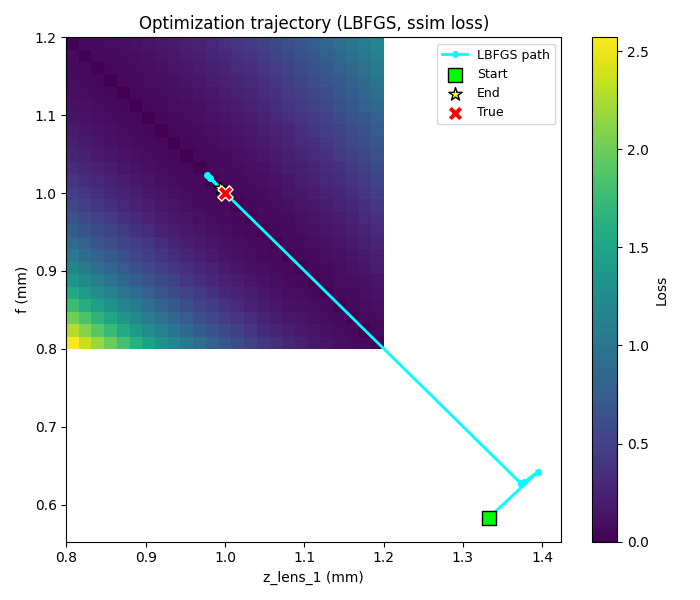

In [13]:
# Plot optimization trajectory on loss landscape

plt.figure(figsize=(7, 6))
plt.imshow(
    np.asarray(loss_grid),
    origin="lower",
    aspect="auto",
    extent=[z_scan[0] * 1e3, z_scan[-1] * 1e3, f_scan[0] * 1e3, f_scan[-1] * 1e3],
    cmap="viridis",
)
plt.colorbar(label="Loss")

z_traj_mm = np.array(z_history) * 1e3
f_traj_mm = np.array(f_history) * 1e3
plt.plot(z_traj_mm, f_traj_mm, marker='o', color='cyan', lw=2, markersize=4, label=f'{optimizer_type.upper()} path')
plt.scatter(z_traj_mm[0], f_traj_mm[0], color='lime', edgecolor='black', s=100, marker='s', label='Start', zorder=10)
plt.scatter(z_traj_mm[-1], f_traj_mm[-1], color='yellow', edgecolor='black', s=100, marker='*', label='End', zorder=10)
plt.scatter(z_lens_1_true * 1e3, f_true * 1e3, color='red', edgecolor='white', s=120, marker='X', label='True', zorder=10)

plt.xlabel("z_lens_1 (mm)")
plt.ylabel("f (mm)")
plt.title(f"Optimization trajectory ({optimizer_type.upper()}, {loss_type_to_use} loss)")
plt.legend(fontsize=9, loc='best')
plt.tight_layout()

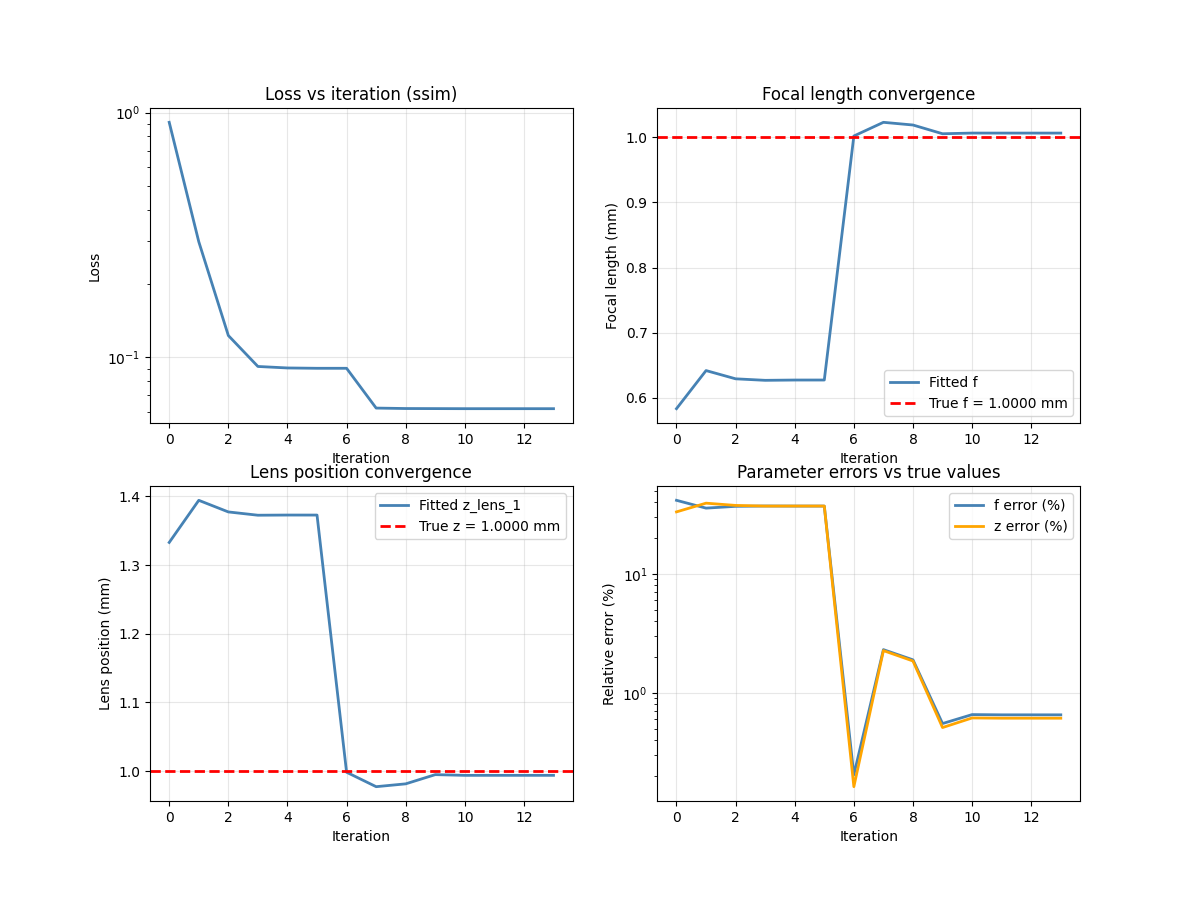

In [14]:
# Convergence analysis

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Loss history
axes[0, 0].plot(loss_history, lw=2, color='steelblue')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title(f'Loss vs iteration ({loss_type_to_use})')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

# Focal length convergence
axes[0, 1].plot(np.array(f_history) * 1e3, lw=2, color='steelblue', label='Fitted f')
axes[0, 1].axhline(f_true * 1e3, color='red', linestyle='--', lw=2, label=f'True f = {f_true*1e3:.4f} mm')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Focal length (mm)')
axes[0, 1].set_title('Focal length convergence')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Lens position convergence
axes[1, 0].plot(np.array(z_history) * 1e3, lw=2, color='steelblue', label='Fitted z_lens_1')
axes[1, 0].axhline(z_lens_1_true * 1e3, color='red', linestyle='--', lw=2, label=f'True z = {z_lens_1_true*1e3:.4f} mm')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Lens position (mm)')
axes[1, 0].set_title('Lens position convergence')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Relative errors
f_errors = np.abs(np.array(f_history) - f_true) / f_true * 100
z_errors = np.abs(np.array(z_history) - z_lens_1_true) / z_lens_1_true * 100
axes[1, 1].semilogy(f_errors, lw=2, label='f error (%)', color='steelblue')
axes[1, 1].semilogy(z_errors, lw=2, label='z error (%)', color='orange')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Relative error (%)')
axes[1, 1].set_title('Parameter errors vs true values')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)


## Summary

This notebook demonstrates lens parameter fitting from defocused intensity images using:
- **Multiple loss functions**: L2, log-intensity, NCC, hybrid, SSIM
- **Physical constraints**: ABCD matrix constraints for imaging geometry
- **Two optimizers**: L-BFGS (fast) and Adam (stable fallback)
- **Smart initialization**: Grid-search from computed loss landscape

**To use this notebook:**
1. Modify `loss_type_to_use` and `optimizer_type` variables in cell 3
2. Adjust constraint weights if needed
3. Run all cells in order
4. Inspect the convergence plots and trajectory visualization

**Key observations:**
- L-BFGS converges in very few steps (~1-10) for this smooth problem
- Adam requires more steps (100-200) but provides an alternative if L-BFGS fails
- Grid-search initialization is crucial for good convergence
- Multi-constraint penalties help enforce physical consistency